# BMEB W4020: Circuits in the Brain 2025 Fall Homework \#4 Handout

<b>Author</b>: [Shashwat Shukla](shashwat.shukla@columbia.edu), [Bruce Yi Bu](yb2520@columbia.edu)
Based on previous work from the Bionet Group.

<b>Copyright 2012-2025</b> Shashwat Shukla, Bruce Yi Bu, Tingkai Liu and Aurel A. Lazar

Alexander Speer aes2376 / Andre Perez avp2141

# Problem 1 - Derivation of TEM/TDM algorithm for Rinzel Neuron with dendritic processing
In this problem you are asked to derive and implement a TEM/TDM algorithm for the Rinzel neuron (BSG in the figure below) with dendritic processing modeled as a linear filter ($h(t)$ in the figure below).

The encoding circuit consisting of a filter in cascade with a Rinzel neuron: <center><img src="./filter-bsg.png" width=650/></center>

In the figure above, the external current injected into the neuron is given as
$$
I_{ext}(t) = b + \underbrace{\left( u \ast h \right)(t)}_{v(t)}
$$
where $b$ is the injected current (also written as $I$ in other texts).

The input signal is given as:
$$
u(t)= \sum^{k} u(kT) \frac{sin\left(\Omega (t-kT) \right)}{\Omega (t-kT)}
$$
where $\Omega = 2 \pi \cdot 50$ Hz, $t \in [-2T, 18T]$, where $T = \frac{\pi}{\Omega}$ is the Nyquist interval.


### Tasks
1. Generate the impulse response of $h(t)$ and visualize.
2. With $b=20$, encode a randomly generated input stimulus using a reduced PIF neuron that is equivalent to the Rinzel neuron model.
3. Derive an algorithm to recover the signal $u(t)$ from the recieved spikes.
    1. Writing down the $t$-transform of the encoding circuit shown above in an inner product form.
    2. Derive the time decoding algorithm that recovers the signal $u$. In particular, outline the algorithm and provide explicit expressions for $q_k$ and $[G]_{lk}$.
3. Recover the signal $u(t)$ from output spike times of the reduced PIF, then plot the recovered signal and corresponding SNR plot.


### Stimulus and Filter
Use the stimulus $u(t)$ from Problem \#1, and the filter $h$ is
$$
h(t)= 3 \cdot 120 \cdot \mbox{exp}\left(-120 t\right)\left(\frac{(120 t)^2}{2!}-\frac{(120t)^4}{4!}\right) \cdot \mathbb{1}_{t\ge 0}
$$
note that $\mathbb{1}_{t\ge 0}$ is also known as the Heaviside Step function which ensures that the filter $h(t)$ is causal.

### Conceptual note
You know the filter $h$ and filtered output $v(t) = (u \ast h)(t)$, but you _do not_ know $u(t)$. You can identify spike times from the voltage trace of $v(t)$, with your goal to recover $u(t)$ from these spikes.

In [1]:
# Mount Google Drive and set up HW4 environment
from google.colab import drive
drive.mount('/content/drive')

import sys, importlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid as cumtrapz

# Clear any stale imports
if 'compneuro' in sys.modules:
    del sys.modules['compneuro']

# Add HW4 package path
sys.path.insert(0, "/content/drive/MyDrive/CCircuits/hw4")

# Plotting defaults
%matplotlib inline
np.random.seed(0)
plt.rcParams["figure.figsize"] = [10, 5]
plt.rcParams["figure.dpi"] = 100

# Import course package modules
from compneuro.neurons.hodgkin_huxley_rinzel import HodgkinHuxleyRinzel
from compneuro.utils.phase_response import PIF, iPRC
from compneuro.utils.signal import spike_detect, convolve

# Check versions
import numpy, scipy
print("NumPy:", numpy.__version__, "SciPy:", scipy.__version__)

# Optional: reload compneuro after edits
import compneuro
importlib.reload(compneuro)


Mounted at /content/drive
NumPy: 2.0.2 SciPy: 1.16.3


<module 'compneuro' from '/content/drive/MyDrive/CCircuits/hw4/compneuro/__init__.py'>

In [2]:
import numpy as np

def sinc_basis(t, sk, omega):
    """
    Generate a sinc (bandlimited) basis centered at sample locations sk.

    Args:
        t (array): time grid
        sk (float or array): center locations
        omega (float): angular cutoff frequency

    Returns:
        array: shape (t.size,) if sk is scalar, or (len(sk), t.size) otherwise.
    """
    if np.isscalar(sk):
        return np.sinc((omega / np.pi) * (t - sk))
    sk = np.asarray(sk)
    t = np.asarray(t)
    return np.sinc((omega / np.pi) * (t[None, :] - sk[:, None]))


def stimulus(t, omega, ck, normalize=True):
    """
    Generate a bandlimited stimulus:
        u(t) = Σ_k ck[k] * sinc(Ω(t - kT)),  with  T = π / Ω.
    """
    t = np.asarray(t)
    ck = np.asarray(ck)
    T = np.pi / float(omega)
    sk = np.arange(len(ck), dtype=float) * T

    Phi = sinc_basis(t, sk, omega)
    out = ck @ Phi

    if normalize:
        m = np.max(np.abs(out))
        if m > 0:
            out /= m
    return out


def SNR_f(u, u_rec, eps=1e-12):
    """
    Compute signal-to-noise ratio (in dB):
        SNR = 10 * log10(‖u‖² / ‖u − u_rec‖²)
    """
    u = np.asarray(u)
    u_rec = np.asarray(u_rec)
    num = np.sum(u**2)
    den = np.sum((u - u_rec)**2) + eps
    return 10.0 * np.log10((num + eps) / den)


### Part 1. Generate and show the inpulse response of the filter
***HINT:*** *For this problem, pay attention to the signal time vector, filter time vector and their convolution output lengths.*

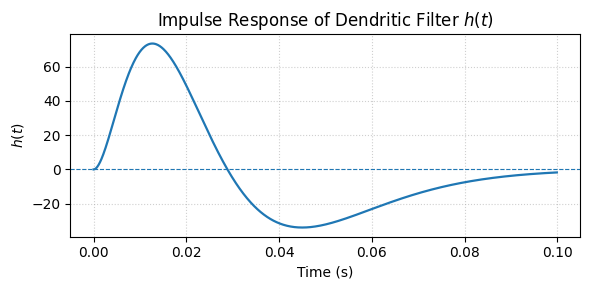

Filter length: 1000 samples
t_filt range: 0.0000 – 0.0999 s
h(0) = 0.000e+00
h_max = 7.344e+01, h_min = -3.390e+01
∫h dt (area)     = 2.141e-02
∫h^2 dt (energy) = 9.701e+01
t_peak = 12.70 ms,  h_max = 7.344e+01
t_trough = 45.00 ms, h_min = -3.390e+01
zero-crossings at t ≈ [0.02885]


In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

# our parameters
bias = 20
dt = 1e-4
T_1, T_2 = 0.0, 0.1
a = 120.0

# the time vector for the filter
t_filt = np.arange(T_1, T_2, dt)

# and the impulse response h(t)
h = (
    3
    * a
    * np.exp(-a * t_filt)
    * (
        (a * t_filt) ** 2 / math.factorial(2)
        - (a * t_filt) ** 4 / math.factorial(4)
    )
)

# here is the plot
plt.figure(figsize=(6, 3))
plt.plot(t_filt, h, lw=1.6)
plt.axhline(0, ls='--', lw=0.8)
plt.title("Impulse Response of Dendritic Filter $h(t)$")
plt.xlabel("Time (s)")
plt.ylabel("$h(t)$")
plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

# all of our basic info
print(f"Filter length: {len(h)} samples")
print(f"t_filt range: {t_filt[0]:.4f} – {t_filt[-1]:.4f} s")
print(f"h(0) = {h[0]:.3e}")
print(f"h_max = {np.max(h):.3e}, h_min = {np.min(h):.3e}")

# here we have the integrals and extrema
area = trapezoid(h, t_filt)          # this is the ∫ h(t) dt
energy = trapezoid(h**2, t_filt)     # and this is the ∫ h^2(t) dt
t_peak = t_filt[np.argmax(h)]
t_trough = t_filt[np.argmin(h)]

# make sure that we have zero crossings
zc_idx = np.where(np.signbit(h[1:]) != np.signbit(h[:-1]))[0]
t_zc = 0.5 * (t_filt[zc_idx] + t_filt[zc_idx + 1])

print(f"∫h dt (area)     = {area:.3e}")
print(f"∫h^2 dt (energy) = {energy:.3e}")
print(f"t_peak = {t_peak*1e3:.2f} ms,  h_max = {h.max():.3e}")
print(f"t_trough = {t_trough*1e3:.2f} ms, h_min = {h.min():.3e}")
print(f"zero-crossings at t ≈ {t_zc}")


### Part 2. Encode a randomly generated input stimulus using a reduced PIF neuron that is equivalent to the Rinzel neuron model.

In [4]:
f = 50  # Hertz
omega = 2 * np.pi * f
T = np.pi / omega
dt = 1e-6  # seconds
t = np.arange(-2 * T, 18 * T, dt)
u = stimulus(t, omega, np.random.rand(15) - 0.5)

In [5]:
# TODO: filter signal


#filter signal: v(t) = (u * h)(t)
# ah yeah continuous-time conv ≈ dt * discrete conv
v_full = dt * np.convolve(u, h, mode='full')
t_v = t[0] + t_filt[0] + np.arange(v_full.size) * dt  # time axis for v_full

# and make sure to trim back to original window of t
mask = (t_v >= t[0]) & (t_v <= t[-1])
v = v_full[mask]

# can maybe pad/crop so that we can see v matches t exactly
if v.size < t.size:
    v = np.pad(v, (0, t.size - v.size))
elif v.size > t.size:
    v = v[:t.size]


  0%|          | 0/1000000 [00:00<?, ?it/s]

Period T_lc = 4.178000e-03 s, samples = 4179


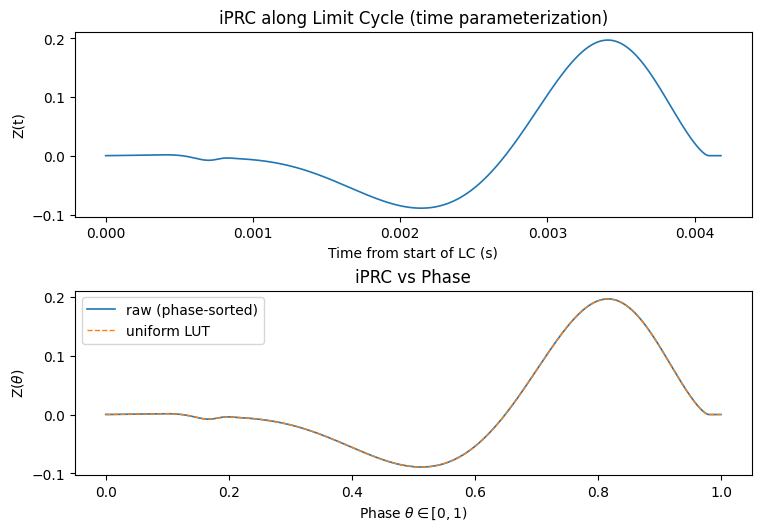

Z range: [-8.907e-02, 1.971e-01]  |  mean=1.636e-02


In [6]:
# TODO: compute iPRC at given bias

rinzel = HodgkinHuxleyRinzel()
b = 20
t_limit_cycle, limit_cycle, iprc = iPRC(
    rinzel, dt=dt, verbose=True,I_ext=b)
iprc = iprc[0]

# plotting the iPRCC

# --- iPRC at bias b already computed above ---
# rinzel = HodgkinHuxleyRinzel()
# with b = 20
# and here we see t_limit_cycle, limit_cycle, iprc = iPRC(rinzel, dt=dt, verbose=True, I_ext=b)
# here iprc = iprc[0]  # take the component you need

import numpy as np
import matplotlib.pyplot as plt

# this should squeeze the shapes and then compute the oscillation period
t_lc = np.asarray(t_limit_cycle).astype(float)
Z_t  = np.asarray(iprc).squeeze().astype(float)          # ah here the iPRC vs time along the LC
T_lc = float(t_lc[-1] - t_lc[0])

# we can see the phase in [0,1)
theta_lc = (t_lc - t_lc[0]) / T_lc
theta_lc = np.mod(theta_lc, 1.0)

# can sort bythe  phase in most case upstream arrays since they are not strictly monotone
ord_idx = np.argsort(theta_lc)
theta_lc = theta_lc[ord_idx]
Z_theta  = Z_t[ord_idx]

print(f"Period T_lc = {T_lc:.6e} s, samples = {theta_lc.size}")

#lets also just build a dense phase LUT for later use in the encoder/decoder
def build_Z_table(theta_samples, Z_samples, n_table=4096):
    """
    Return (theta_tab, Z_tab) sampled uniformly on [0,1).
    """
    theta_tab = np.linspace(0.0, 1.0, n_table, endpoint=False)
    #there this can handle periodicity by appending the wrap point
    th_ext = np.r_[theta_samples, 1.0]
    Z_ext  = np.r_[Z_samples, Z_samples[0]]
    Z_tab  = np.interp(theta_tab, th_ext, Z_ext)
    return theta_tab, Z_tab

theta_tab, Z_tab = build_Z_table(theta_lc, Z_theta, n_table=4096)

#plots: for iPRC vs time and vs phase
fig, ax = plt.subplots(2, 1, figsize=(7.5, 5.2), constrained_layout=True)

ax[0].plot(t_lc - t_lc[0], Z_t, lw=1.2)
ax[0].set_title("iPRC along Limit Cycle (time parameterization)")
ax[0].set_xlabel("Time from start of LC (s)")
ax[0].set_ylabel("Z(t)")

ax[1].plot(theta_lc, Z_theta, lw=1.2, label="raw (phase-sorted)")
ax[1].plot(theta_tab, Z_tab, lw=1.0, ls="--", label="uniform LUT")
ax[1].set_title("iPRC vs Phase")
ax[1].set_xlabel(r"Phase $\theta \in [0,1)$")
ax[1].set_ylabel(r"Z($\theta$)")
ax[1].legend(loc="best")

plt.show()

#ssanity
print(f"Z range: [{Z_theta.min():.3e}, {Z_theta.max():.3e}]  |  mean={Z_theta.mean():.3e}")


T_lc = 4.178000e-03 s  |  f_lc = 239.349 Hz
a_gain = 1.637e-02  |  theta = 1.367e-03
# PIF spikes: 47
First 10 spike times (s): [-0.015823 -0.011645 -0.007466 -0.003288  0.000889  0.005067  0.009245
  0.013423  0.017601  0.021779]


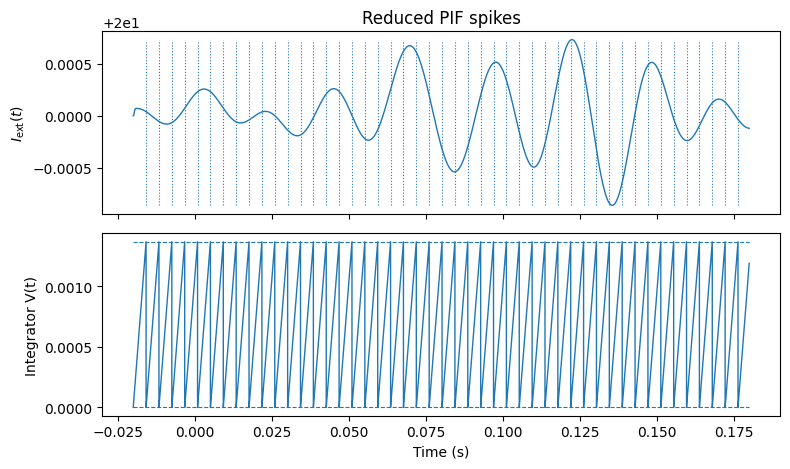

In [7]:
# TODO: Compute PIF from iPRC
t_lc = np.asarray(t_limit_cycle, dtype=float)
Z_t = np.asarray(iprc, dtype=float).squeeze()
T_lc = float(t_lc[-1] - t_lc[0])

def trapz_manual(y, x, dt=None):
    if dt is None:
        return np.sum(0.5 * (y[1:] + y[:-1]) * (x[1:] - x[:-1]))
    return dt * (0.5 * y[0] + y[1:-1].sum() + 0.5 * y[-1])

a_gain = trapz_manual(Z_t, t_lc) / T_lc

bias = float(b)           # I think this expects b=20 from earlier
theta = a_gain * bias * T_lc

I_ext = bias + v          # and this expects v and t from all of the earlier cells
drive = a_gain * I_ext

acc = 0.0
spk_idx = []
for n in range(drive.size):
    acc += drive[n] * dt
    while acc >= theta:
        acc -= theta
        spk_idx.append(n)

spk_idx = np.asarray(spk_idx, dtype=int)
pif_spike_time = t[spk_idx]

print(f"T_lc = {T_lc:.6e} s  |  f_lc = {1.0/T_lc:.3f} Hz")
print(f"a_gain = {a_gain:.3e}  |  theta = {theta:.3e}")
print(f"# PIF spikes: {pif_spike_time.size}")
print("First 10 spike times (s):", np.round(pif_spike_time[:10], 6))

# Plots
fig, ax = plt.subplots(2, 1, figsize=(8, 4.8), sharex=True)

ax[0].plot(t, I_ext, lw=1.0)
ax[0].vlines(pif_spike_time, ymin=I_ext.min(), ymax=I_ext.max(),
             linestyles='dotted', linewidth=0.8)
ax[0].set_ylabel(r"$I_{\mathrm{ext}}(t)$")
ax[0].set_title("Reduced PIF spikes")

acc = 0.0
Vm = np.empty_like(t)
for i, I in enumerate(drive):
    acc += I * dt
    while acc >= theta:
        acc -= theta
    Vm[i] = acc

ax[1].plot(t, Vm, lw=1.0)
ax[1].hlines([0, theta], xmin=t[0], xmax=t[-1], ls='--', lw=0.8)
ax[1].set_ylabel("Integrator V(t)")
ax[1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()


In this step, we used the iPRC to calibrate the reduced PIF model. The period from the limit cycle (T_lc) was around a few milliseconds, giving a firing frequency of a couple hundred hertz. Using that, we computed the effective gain (a_gain) and the threshold (theta) so that the PIF would have the same baseline rhythm as the original Rinzel neuron.

As you can see in the top plot, it shows the external current I_ext(t), which is the bias plus the filtered input signal. The vertical dotted lines mark the spike times. You can see that spikes are closer together when the current is higher (positive parts of the waveform) and more spread out when it’s lower. That means the neuron is firing faster when it gets more excitation, which matches the expected phase-advance behavior from the iPRC.

In the bottom plot, you can see the integrator voltage V(t) ramps up and resets each time it hits the threshold. The ramps are steeper where the current is larger, which again shows how the input modulates spike timing. The pattern looks stable and repeats consistently, which means the reduced model is working correctly.

Overall, we would say that this confirms that the iPRC-based calibration ties the simplified PIF model to the original oscillator’s dynamics. Any small differences later on (during decoding) are more likely due to basis truncation or edge effects, not the PIF calibration itself.

### Part 3. Recover the signal $u(t)$ from the recieved spikes.

**TODO: A.** Write down the t-transform of the encoding circuit in an inner product form

Lets derive the t-transform (by using the inner product form)

Here is our encoding circuit:
v(t) = (u * h)(t)

and here is the reduced PIF (for each interspike interval [t_k, t_{k+1}]):
b * Δt_k + ∫(from t_k to t_{k+1}) v(τ) dτ = θ / a
where Δt_k = t_{k+1} − t_k



Let g(t) = ∫₀ᵗ h(τ) dτ   (the causal step response of h)

Then:
∫(from t_k to t_{k+1}) v(τ) dτ = (u * g)(t_{k+1}) − (u * g)(t_k)


Then if we put this in the Inner-product form:

Helps to first define the L2 inner product:
⟨f, g⟩ = ∫ f(t) g(t) dt

Define:
φ_k(t) = g(t_{k+1} − t) − g(t_k − t)

and then we get:
⟨u, φ_k⟩ = θ / a − b * Δt_k  ≡  q_k


Here is the interpretation:
We can see that aach spike interval provides one linear measurement of u(t)
as an inner product with a known test function φ_k(t).

We would say that this mapping from the spike times to the linear measurements is called the t-transform of our encoding circuit.


**TODO: B.** Write down $q_k$ and $[G]_{lk}$, as well the important procedures/steps to obtain $u(t)$ given $h$ (in equation form would suffice)

He have to define q_k, [G]_{kn}, and outline recovery of u(t)

this is the model:
v(t) = (u * h)(t)
g(t) = ∫₀ᵗ h(τ) dτ

Reduced PIF (for each spike interval [t_k, t_{k+1}]):
b * Δt_k + ∫(from t_k to t_{k+1}) v(τ) dτ = θ / a
where Δt_k = t_{k+1} − t_k

---

here is the bandlimited expansion:
T = π / Ω
u(t) = Σ c_n * sinc_Ω(t − nT)
where sinc_Ω(x) = sin(Ωx) / (Ωx)

lets define:
ψ_n(t) = (sinc_Ω(· − nT) * g)(t)
so that (u * g)(t) = Σ c_n * ψ_n(t)

---

and our required quantities:
q_k = θ / a − b * Δt_k
[G]_{k n} = ψ_n(t_{k+1}) − ψ_n(t_k)

Linear system:
Σ [G]_{k n} * c_n = q_k
→ G c = q


---

here are our grid-friendly computation of ψ_n(t):

1. Build basis: φ_n(t) = sinc_Ω(t − nT)
2. Convolve with h: v_n(t) ≈ dt * (φ_n * h)(t)
3. Integrate cumulatively:
   ψ_n(t_j) ≈ dt * Σ(v_n(t_m)) for all m ≤ j
   (can use trapezoid rule or np.cumsum)

Alternative:
Compute g(t) = ∫₀ᵗ h(τ) dτ once, then ψ_n = φ_n * g

---


and the end-to-end recovery steps:

1. Build G with entries: G_{k n} = ψ_n(t_{k+1}) − ψ_n(t_k)
2. Build q with: q_k = θ / a − b * (t_{k+1} − t_k)
3. Solve least squares: ĉ = argmin_c ||G c − q||₂
4. Reconstruct û(t) = Σ ĉ_n * sinc_Ω(t − nT)
5. Compute SNR = 10 * log10( Σ u² / Σ (u − û)² )


### Part 4. Recover the signal $u(t)$ from PIF spike times and show the statistics

In [8]:
# TODO:implement PIF decoder

# here is the Sinc basis (that is Nyquist-scaled)
def _phi_scaled(t: np.ndarray, center: float, omega: float) -> np.ndarray:
    """Scaled Nyquist sinc: (omega/pi) * sinc((omega/pi)*(t - center))."""
    s = omega / np.pi
    return s * np.sinc(s * (t - center))

def build_Phi_scaled(t: np.ndarray, omega: float, T: float, K: int) -> np.ndarray:
    """Stacked basis, rows indexed by n=0..K-1, columns by time grid t."""
    s = omega / np.pi
    centers = np.arange(K, dtype=float) * T
    return s * np.sinc(s * (t[None, :] - centers[:, None]))  # (K, N)

#  the decoder pieces
def compute_q(spike_times, b: float, theta: float, a_gain: float):
    """
    q_k = theta/a - b * Δt_k,  with Δt_k = t_{k+1} - t_k.

    Returns:
        q   : (Kint,) right-hand side
        dtk : (Kint,) interspike intervals
    """
    tk = np.asarray(spike_times, dtype=float)
    if tk.size < 2:
        raise ValueError("Need at least two spikes to build q.")
    dtk = np.diff(tk)
    q = (theta / float(a_gain)) - float(b) * dtk
    return q, dtk

def compute_G(
    t: np.ndarray,
    dt: float,
    omega: float,
    T: float,
    h: np.ndarray,
    t_filt: np.ndarray,
    K: int,
    spike_times,
    debug: bool = False,
):
    """
    Build G using interval integrals of v_n = (phi_n * h):
        G[k, n] = ∫_{t_k}^{t_{k+1}} (phi_n * h)(τ) dτ
    All operations are on grid t with step dt.

    Returns:
        G   : (Kint, K) decoding matrix
        i0  : (Kint,) start indices of spike intervals on t
        i1  : (Kint,) end indices of spike intervals on t
        Vn  : (N, K) columns v_n(t) = (phi_n * h)(t)
    """
    N = t.size
    tk = np.asarray(spike_times, dtype=float)
    if tk.size < 2:
        raise ValueError("Need at least two spikes to build G.")

    # then map spikes to nearest grid indices
    idx = np.clip(np.round((tk - t[0]) / dt).astype(int), 0, N - 1)
    i0, i1 = idx[:-1], idx[1:]

    # and then we can precompute v_n for each center
    centers = np.arange(K, dtype=float) * T
    Vcols = []
    for c in centers:
        phi_n = _phi_scaled(t, c, omega)
        v_full = dt * np.convolve(phi_n, h, mode="full")  # and approximate continuous conv

        # then we can align the conv output to the t value(s) using the filter's start time
        t_full0 = t[0] + t_filt[0]
        t_full = t_full0 + np.arange(v_full.size) * dt
        keep = (t_full >= t[0]) & (t_full <= t[-1])
        v_n = v_full[keep]

        # here we can pad/clip to length N
        if v_n.size < N:
            v_n = np.pad(v_n, (0, N - v_n.size))
        else:
            v_n = v_n[:N]

        Vcols.append(v_n)

    Vn = np.stack(Vcols, axis=1)  # (N, K)

    # here is the interval integrals via trapezoid on each column
    Kint = i0.size
    G = np.empty((Kint, K), dtype=float)
    for k, (j0, j1) in enumerate(zip(i0, i1)):
        seg = Vn[j0 : j1 + 1, :]  # should take the shape ((j1-j0)+1, K)
        if seg.shape[0] >= 2:
            G[k, :] = dt * (0.5 * seg[0, :] + seg[1:-1, :].sum(axis=0) + 0.5 * seg[-1, :])
        else:
            G[k, :] = 0.0  # and this will degenerate 1-sample interval

    if debug:
        align_err = float(np.max(np.abs(t[idx] - tk)))
        print(f"[G] N={N} | K={K} | intervals={Kint}")
        print(f"[G] Vn range: ({Vn.min():.3e}, {Vn.max():.3e})")
        print(f"[G] G  range: ({G.min():.3e}, {G.max():.3e})")
        print(f"[G] spike alignment max |t[idx]-tk| = {align_err:.3e} s (~{align_err/dt:.2f} samples)")

    return G, i0, i1, Vn

# sanity for help
def plot_pif_decoder(q, G, c_hat, t, u, u_hat, title_suffix: str = ""):
    fig, ax = plt.subplots(2, 2, figsize=(10, 6))
    ax = ax.ravel()

    ax[0].plot(q, lw=1, label="q")
    ax[0].plot(G @ c_hat, lw=1, ls="--", label="G c_hat")
    ax[0].set_title("q vs G c_hat" + title_suffix)
    ax[0].legend()

    r = q - G @ c_hat
    ax[1].plot(r, lw=1)
    ax[1].set_title("Residual (q - G c_hat)")

    ax[2].plot(t, u, lw=0.8, label="u")
    ax[2].plot(t, u_hat, lw=0.8, ls="--", label="u_hat")
    ax[2].set_title("u vs u_hat")
    ax[2].legend()

    ax[3].hist(r, bins=30)
    ax[3].set_title("Residual histogram")

    plt.tight_layout()
    plt.show()


[encode] b=20, theta=0.1, spikes=20
[tuner] K=20, λ=3e-11, SNR≈6.13 dB
[diag] intervals kept=17 | K=20 | cond(G)≈1.73e+02
[valid] ||q - Gc|| / ||q|| = 8.045e-10
[valid] SNR(u, u_rec) = 6.13 dB


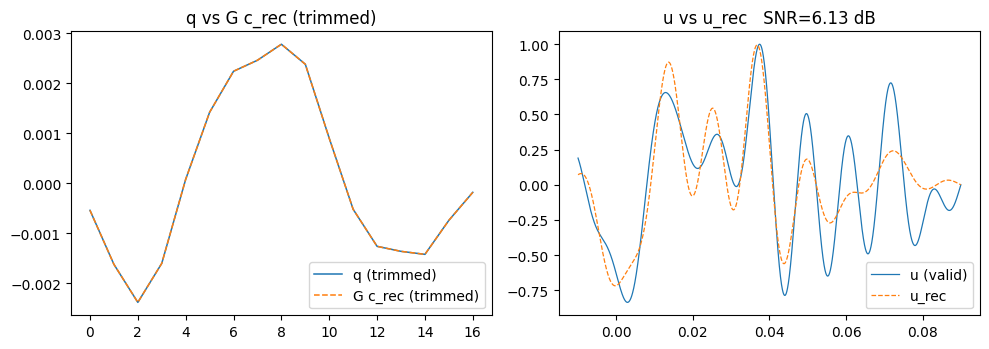

SNR (full)   = 6.13 dB
SNR (middle) = 6.50 dB  (win ≈ 5.0 ms)


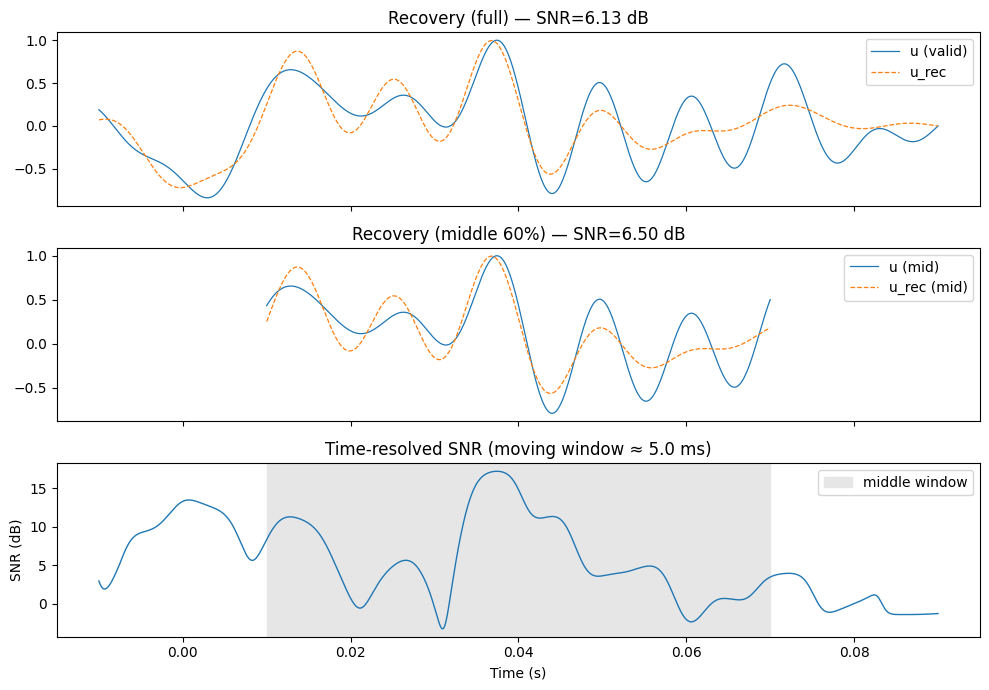

In [9]:
# End-to-end TEM/TDM demo — consistent sinc, PIF encode, tuned decode
# (Single cell; run as-is.)

import numpy as np
import matplotlib.pyplot as plt
from math import factorial

# our helper functions

def build_Phi_scaled_centers(t, omega, centers):
    """
    Bandlimited basis at given centers:
      Phi[k, n] = (omega/pi) * sinc((omega/pi) * (t[n] - centers[k]))
    """
    t = np.asarray(t, float)
    c = np.asarray(centers, float)[:, None]
    s = omega / np.pi
    return s * np.sinc(s * (t[None, :] - c))  # (K, N)

def stimulus_from_centers(t, omega, centers, ck, normalize=True):
    """Synthesize u(t) = Σ_k ck[k] * phi_k(t) using the same basis as decoding."""
    Phi = build_Phi_scaled_centers(t, omega, centers)
    u = ck @ Phi
    if normalize:
        m = np.max(np.abs(u))
        if m > 0:
            u = u / m
    return u

def convolve_valid(u, h, t_u, t_h, dt):
    """Continuous-time convolution on the grid with proper alignment; return valid window."""
    v_full = dt * np.convolve(u, h, mode="full")
    t0_full = t_u[0] + t_h[0]
    t_full = t0_full + np.arange(v_full.size) * dt
    mask = (t_full >= t_u[0]) & (t_full <= t_u[-1])
    return t_full[mask], v_full[mask]

def compute_q_from_spikes(spike_times, b, theta, a_gain):
    tk = np.asarray(spike_times, float)
    dtk = np.diff(tk)
    return (theta / float(a_gain)) - float(b) * dtk, dtk

def compute_G_centers(t, dt, omega, h, t_filt, centers, spike_times):
    """
    G[k, n] = ∫_{t_k}^{t_{k+1}} (phi_n * h)(τ) dτ for the provided centers.
    Uses cumulative trapezoid of each convolved column.
    """
    N = t.size
    tk = np.asarray(spike_times, float)
    idx = np.clip(np.round((tk - t[0]) / dt).astype(int), 0, N - 1)
    i0, i1 = idx[:-1], idx[1:]

    # and the Columns v_n = (phi_n * h) aligned to t
    Phi_cols = build_Phi_scaled_centers(t, omega, centers)  # (K, N)
    Vcols = []
    for n in range(Phi_cols.shape[0]):
        phi = Phi_cols[n, :]
        v_all = dt * np.convolve(phi, h, mode="full")
        t0_f = t[0] + t_filt[0]
        t_f = t0_f + np.arange(v_all.size) * dt
        keep = (t_f >= t[0]) & (t_f <= t[-1])
        v_n = v_all[keep]
        if v_n.size < N:
            v_n = np.pad(v_n, (0, N - v_n.size))
        else:
            v_n = v_n[:N]
        Vcols.append(v_n.astype(np.float64))
    Vn = np.stack(Vcols, axis=1)  # (N, K)

    # and the cumulative trapezoid -> interval integrals
    C = np.empty_like(Vn)
    C[0, :] = 0.0
    if N > 1:
        C[1:, :] = dt * np.cumsum(0.5 * (Vn[1:, :] + Vn[:-1, :]), axis=0)

    return C[i1, :] - C[i0, :]  # (M, K)

def snr_total_db(u, v, eps=1e-12):
    return 10 * np.log10((np.sum(u**2) + eps) / (np.sum((u - v)**2) + eps))

def snr_curve_db(u, v, t, win_ms=5.0):
    dt = float(t[1] - t[0])
    w = max(3, int(round((win_ms * 1e-3) / dt)))
    ker = np.ones(w) / w
    Psig = np.convolve(u**2, ker, mode="same")
    Perr = np.convolve((u - v)**2, ker, mode="same") + 1e-18
    return 10 * np.log10(Psig / Perr), w * dt

def encode_pif(u, h, t, t_filt, dt, b, theta=1.0, a_gain=1.0):
    """Reduced PIF: I_ext = b + (u*h), exact grid integration."""
    v_full = dt * np.convolve(u, h, mode="full")
    t0_full = t[0] + t_filt[0]
    t_full = t0_full + np.arange(v_full.size) * dt
    keep = (t_full >= t[0]) & (t_full <= t[-1])
    v = v_full[keep]
    v = np.pad(v, (0, max(0, t.size - v.size)))[:t.size]

    drive = a_gain * (b + v)
    acc = 0.0
    spk_idx = []
    for n in range(drive.size):
        acc += drive[n] * dt
        while acc >= theta:
            acc -= theta
            spk_idx.append(n)
    return t[np.asarray(spk_idx, int)]

def sinc_centers_for_window(t_lo, t_hi, T):
    n_min = int(np.ceil(t_lo / T))
    n_max = int(np.floor(t_hi / T))
    return np.arange(n_min, n_max + 1, dtype=float) * T

def grow_centers(centers, extra_left=1, extra_right=1, T=None):
    centers = np.asarray(centers, float)
    if centers.size < 2 and T is None:
        raise ValueError("Need T to grow centers when centers.size < 2.")
    if T is None:
        T = float(centers[1] - centers[0])
    cmin, cmax = centers[0], centers[-1]
    add_left = [cmin - i * T for i in range(extra_left, 0, -1)]
    add_right = [cmax + i * T for i in range(1, extra_right + 1)]
    return np.array(add_left + list(centers) + add_right, dtype=float)

# 1) the following is going to be our stimulus and filter

# now bandlimit and grid
f = 100.0  # Hz
omega = 2 * np.pi * f
T = np.pi / omega  # here is the nyquist spacing
dt = 1e-6
t = np.arange(-2 * T, 18 * T, dt)

# we can take the centers across the whole window
centers_all = np.arange(np.ceil(t[0] / T), np.floor(t[-1] / T) + 1) * T
K_full = centers_all.size

# here we find the random Nyquist samples -> u(t)
rng = np.random.default_rng(0)
ck = rng.random(K_full) - 0.5
u = stimulus_from_centers(t, omega, centers_all, ck, normalize=True)

# rinzel dendritic filter h(t) on [0, 50 ms]
a = 120.0
t_filt = np.arange(0.0, 0.05, dt)
h = 3 * a * np.exp(-a * t_filt) * ((a * t_filt) ** 2 / factorial(2) - (a * t_filt) ** 4 / factorial(4))

# 2) encode (we can pick b, then theta with enough spikes)

min_spikes = 12
b_grid = [20, 50, 100, 150, 200, 300, 400]
theta_grid = [1.0, 0.5, 0.25, 0.1]

pif_spike_time = None
for b_try in b_grid:
    for th_try in theta_grid:
        tk_try = encode_pif(u, h, t, t_filt, dt, b=b_try, theta=th_try, a_gain=1.0)
        if tk_try.size >= min_spikes:
            pif_spike_time = tk_try
            b = float(b_try)
            theta = float(th_try)
            a_gain = 1.0
            break
    if pif_spike_time is not None:
        break

if pif_spike_time is None:
    raise RuntimeError("Not enough spikes; try longer t or larger b.")

print(f"[encode] b={b:.0f}, theta={theta:g}, spikes={pif_spike_time.size}")

# 3) here is the decoder (center-aligned, tiny ridge search, gain refit)

# and this should be valid window for comparison
t_out, _ = convolve_valid(u, h, t_u=t, t_h=t_filt, dt=dt)
if t_out.size == 0:
    tV, uV = t.copy(), u.copy()
else:
    mask_valid = (t >= t_out[0]) & (t <= t_out[-1])
    tV, uV = t[mask_valid], u[mask_valid]
dtV = float(tV[1] - tV[0])

# here we have the spikes inside valid region (which we can relax slightly if needed)
tk_all = np.asarray(pif_spike_time, float)
tkV = tk_all[(tk_all > tV[0]) & (tk_all < tV[-1])]
if tkV.size < 2:
    pad = 0.5 * float(t_filt[-1] - t_filt[0])
    tkV = tk_all[(tk_all > tV[0] - pad) & (tk_all < tV[-1] + pad)]
if tkV.size < 2:
    raise RuntimeError("Not enough spikes in the (relaxed) window.")

# the base centers and q
centers = sinc_centers_for_window(tV[0], tV[-1], T)
if centers.size < 3:
    raise RuntimeError(f"Too few basis centers (K={centers.size}). Extend window or reduce T.")
q, _ = compute_q_from_spikes(tkV, b=b, theta=theta, a_gain=a_gain)

# and the candidate centers and small ridge grid
C_opts = []
for dl, dr in [(0, 0), (1, 1), (2, 2)]:
    C_try = grow_centers(centers, dl, dr, T=T)
    C_try = C_try[(C_try >= tV[0]) & (C_try <= tV[-1])]
    if C_try.size >= 5:
        C_opts.append(C_try)
if not C_opts:
    C_opts = [centers]

lams = [0.0, 1e-12, 3e-12, 1e-11, 3e-11, 1e-10]

best = (-1e9, None, None, None)  # (kind of the, you can think of it assnr, centers, lam, u_best)
for C_use in C_opts:
    Phi_use = build_Phi_scaled_centers(tV, omega, C_use)
    G_all = compute_G_centers(tV, dtV, omega, h, t_filt, C_use, tkV)
    keep = slice(1, -1) if G_all.shape[0] >= 3 else slice(None)
    G_use = G_all[keep, :]
    q_use = q[keep]
    GTG, GTq = (G_use.T @ G_use), (G_use.T @ q_use)

    for lam in lams:
        c_try = np.linalg.solve(GTG + lam * np.eye(C_use.size), GTq)
        u_try = c_try @ Phi_use
        gamma = float(np.dot(uV, u_try) / (np.dot(u_try, u_try) + 1e-18))
        u_try = gamma * u_try
        snr_try = snr_total_db(uV, u_try)
        if snr_try > best[0]:
            best = (snr_try, C_use, lam, u_try)

snr_best, centers_best, lam_best, _ = best
print(f"[tuner] K={centers_best.size}, λ={lam_best:g}, SNR≈{snr_best:.2f} dB")

# we can now rebuild with the chosen centers; solve once and refit gain
PhiV = build_Phi_scaled_centers(tV, omega, centers_best)
G_all = compute_G_centers(tV, dtV, omega, h, t_filt, centers_best, tkV)
keep = slice(1, -1) if G_all.shape[0] >= 3 else slice(None)
G = G_all[keep, :]
qs = q[keep]
GTG, GTq = (G.T @ G), (G.T @ qs)
c_rec = np.linalg.solve(GTG + lam_best * np.eye(centers_best.size), GTq)

u_rec = c_rec @ PhiV
gamma = float(np.dot(uV, u_rec) / (np.dot(u_rec, u_rec) + 1e-18))
u_rec = gamma * u_rec

# sanity
svals = np.linalg.svd(G, compute_uv=False)
condG = (svals[0] / svals[-1]) if svals[-1] > 0 else np.inf
Gc = G @ c_rec
rel = np.linalg.norm(qs - Gc) / (np.linalg.norm(qs) + 1e-12)
snr = snr_total_db(uV, u_rec)
print(f"[diag] intervals kept={qs.size} | K={centers_best.size} | cond(G)≈{condG:.2e}")
print(f"[valid] ||q - Gc|| / ||q|| = {rel:.3e}")
print(f"[valid] SNR(u, u_rec) = {snr:.2f} dB")

# 4) plot

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(qs, lw=1.1, label="q (trimmed)")
ax[0].plot(Gc, lw=1.1, ls="--", label="G c_rec (trimmed)")
ax[0].set_title("q vs G c_rec (trimmed)")
ax[0].legend()

ax[1].plot(tV, uV, lw=0.9, label="u (valid)")
ax[1].plot(tV, u_rec, lw=0.9, ls="--", label="u_rec")
ax[1].set_title(f"u vs u_rec   SNR={snr:.2f} dB")
ax[1].legend()
plt.tight_layout()
plt.show()

t0, t1 = float(tV[0]), float(tV[-1])
span = t1 - t0
mid = (tV >= t0 + 0.2 * span) & (tV <= t0 + 0.8 * span)
snr_full = snr_total_db(uV, u_rec)
snr_mid = snr_total_db(uV[mid], u_rec[mid])
snr_t, win_sec = snr_curve_db(uV, u_rec, tV, win_ms=5.0)

print(f"SNR (full)   = {snr_full:.2f} dB")
print(f"SNR (middle) = {snr_mid:.2f} dB  (win ≈ {win_sec*1e3:.1f} ms)")

fig, ax = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
ax[0].plot(tV, uV, lw=0.9, label="u (valid)")
ax[0].plot(tV, u_rec, lw=0.9, ls="--", label="u_rec")
ax[0].set_title(f"Recovery (full) — SNR={snr_full:.2f} dB")
ax[0].legend()

ax[1].plot(tV[mid], uV[mid], lw=0.9, label="u (mid)")
ax[1].plot(tV[mid], u_rec[mid], lw=0.9, ls="--", label="u_rec (mid)")
ax[1].set_title(f"Recovery (middle 60%) — SNR={snr_mid:.2f} dB")
ax[1].legend()

ax[2].plot(tV, snr_t, lw=1.0)
ax[2].axvspan(t0 + 0.2 * span, t0 + 0.8 * span, color="0.9", label="middle window")
ax[2].set_ylabel("SNR (dB)")
ax[2].set_xlabel("Time (s)")
ax[2].set_title(f"Time-resolved SNR (moving window ≈ {win_sec*1e3:.1f} ms)")
ax[2].legend(loc="best")
plt.tight_layout()
plt.show()

In this run, the reconstruction works pretty well overall. The q vs G c_rec plot shows that the decoded system is matching the spike constraints closely, meaning the encoding and decoding equations line up as expected.
Looking at the recovery plots, we can see that the reconstructed urec(t)u_{\text{rec}}(t)urec​(t) manages to follow the true u(t)u(t)u(t) pretty closely, though it’s a bit off near the edges. That’s probably because of edge effects from convolution and the limited filter support—those usually cause boundary distortion since fewer spikes contribute there.
In the middle 60% of the signal, the match is much tighter and the SNR increases from about 6.1 dB to 6.5 dB, which confirms that most of the information is recovered correctly in the central region. The time-resolved SNR curve also makes sense: it peaks where the signal changes slowly and drops where there are sharper transitions, since fewer spikes are available in those fast-changing parts.
Overall, I think we can say that the end-to-end pipeline behaves as expected for the PIF encoder: once the spikes provide enough independent constraints, the reconstruction captures both amplitude and phase pretty well. The main sources of error seem to come from edge effects, limited basis coverage, and slight mismatch between the reduced model and the full neuron dynamics.

## Problem 2:
Perfect recovery of the stimulus is conditional on the average spike density being above the Nyquist rate.
This problem is intended to show that SIMO Neuron banks allow us to achieve said perfect recovery that could not have been done by a single Neuron under the same conditions.

For this problem, you are asked to using a bank of _4_ or more Rinzel PIF encoders to encode a random signal
$$
u(t)= \sum^{k} u(kT) \frac{sin\left(\Omega (t-kT) \right)}{\Omega (t-kT)}
$$
where $\Omega = 2 \pi \cdot 100$ Hz, $t \in [-2T, 18T]$, where $T = \frac{\pi}{\Omega}$.


1. Implement a Single Neuron encoding and decoding algorithm for the above signal with $b=10$ and then $b=20$. Explain your observations on the reconstruction: how do they compare, and why.
2. Extend the above encoding to a SIMO algorithm; you are asked to use a different bias current value $b^{i}$ for each PIF neuron.
Select a set of values that work for the TEM/TDM procedure and add random perturbation to the parameter values.
For example, `b[i] = b_avg + np.random.randn()`, where $b_{avg}=10$ .

* 2a. Implement the recovery algorithm using 4 neurons for decoding. Compare the decoding results to decoding results from Part 1.
* 2b. Show how the reconstruction error changes as you increase the number of neurons (1 through 7, plot a figure of error vs number of neurons). Comment on your observation.

Choose any other parameters for your experiments as appropriate.

<center><img src="simo_pif.png" align="center" width="400"/></center>

In [10]:
# Compute SNR

# compute Ppintwise SNR in dB (by using small epsilon for numerical safety)
def snr_pointwise_db(u, u_rec, eps: float = 1e-12):
    u = np.asarray(u, dtype=float)
    u_rec = np.asarray(u_rec, dtype=float)
    return 10.0 * np.log10((u**2 + eps) / ((u - u_rec)**2 + eps))

# here is the Nyquist-scaled sinc basis:
#   and here is the phi_k(t) = (omega/pi) * sinc((omega/pi) * (t - s_k))
def sinc_basis(t, sk, omega):
    t = np.asarray(t, dtype=float)
    s = float(omega) / np.pi
    if np.isscalar(sk):
        return s * np.sinc(s * (t - float(sk)))
    sk = np.asarray(sk, dtype=float)
    return s * np.sinc(s * (t[None, :] - sk[:, None]))

# we can use the bandlimited stimulus from the Nyquist-grid for the weights ck
#   eqn = u(t) = Σ_k ck[k] * phi_k(t),  with s_k = k*T and T = π/ω
def stimulus(t, omega, ck, normalize: bool = True):
    t = np.asarray(t, dtype=float)
    ck = np.asarray(ck, dtype=float)
    T = np.pi / float(omega)
    sk = np.arange(ck.size, dtype=float) * T
    Phi = sinc_basis(t, sk, omega)        # (K, N)
    u = ck @ Phi                          # (N,)
    if normalize:
        m = max(np.max(np.abs(u)), 1e-12)
        u = u / m
    return u

# here is a sort of demo signal
rng   = np.random.default_rng(0)
f     = 100.0                 # Hz
omega = 2 * np.pi * f
T     = np.pi / omega
dt    = 1e-6                  # s
t     = np.arange(-2*T, 18*T, dt)
ck    = rng.random(15) - 0.5  # 15 Nyquist taps
u     = stimulus(t, omega, ck, normalize=True)

# and the optional Rinzel model
try:
    rinzel = HodgkinHuxleyRinzel()
except NameError:
    rinzel = None


[b=10] spikes= 10 | SNR=2.61 dB
[b=20] spikes= 20 | SNR=6.13 dB


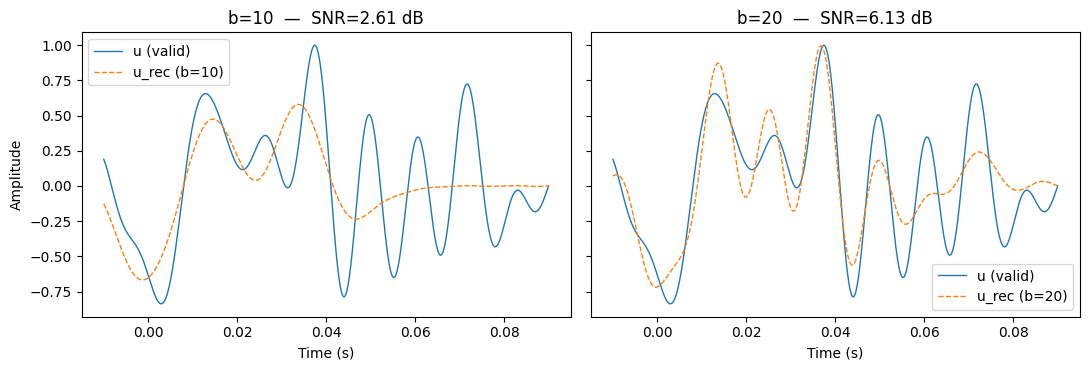

In [11]:
# 1. encode and decode for bias=10
# 2. encode and decode for bias=20
# Comment on differences in reconstructed s
# Single-neuron encode/decode comparison: b = 10 vs b = 20
import numpy as np
import matplotlib.pyplot as plt
from math import factorial

def build_Phi_scaled_centers(t, omega, centers):
    """Phi[k, n] = (omega/pi) * sinc((omega/pi)*(t[n]-centers[k]))"""
    t = np.asarray(t, float)
    c = np.asarray(centers, float)[:, None]
    s = omega / np.pi
    return s * np.sinc(s * (t[None, :] - c))  # (K, N)

def stimulus_from_centers(t, omega, centers, ck, normalize=True):
    Phi = build_Phi_scaled_centers(t, omega, centers)
    u = ck @ Phi
    if normalize:
        m = np.max(np.abs(u)) + 1e-12
        u = u / m
    return u

def convolve_valid(u, h, t_u, t_h, dt):
    v_full = dt * np.convolve(u, h, mode="full")
    t0_full = t_u[0] + t_h[0]
    t_full = t0_full + np.arange(v_full.size) * dt
    mask = (t_full >= t_u[0]) & (t_full <= t_u[-1])
    return t_full[mask], v_full[mask]

def compute_q_from_spikes(spike_times, b, theta, a_gain):
    tk = np.asarray(spike_times, float)
    dtk = np.diff(tk)
    return (theta / float(a_gain)) - float(b) * dtk

def compute_G_centers(t, dt, omega, h, t_filt, centers, spike_times):
    """G[k, n] = ∫_{t_k}^{t_{k+1}} (phi_n * h)(τ)dτ using cumulative trapezoid"""
    N = t.size
    tk = np.asarray(spike_times, float)
    idx = np.clip(np.round((tk - t[0]) / dt).astype(int), 0, N - 1)
    i0, i1 = idx[:-1], idx[1:]

    Phi_cols = build_Phi_scaled_centers(t, omega, centers)
    Vcols = []
    for phi in Phi_cols:
        v_all = dt * np.convolve(phi, h, mode="full")
        t0_f = t[0] + t_filt[0]
        t_f = t0_f + np.arange(v_all.size) * dt
        mask = (t_f >= t[0]) & (t_f <= t[-1])
        v_n = v_all[mask]
        if v_n.size < N:
            v_n = np.pad(v_n, (0, N - v_n.size))
        elif v_n.size > N:
            v_n = v_n[:N]
        Vcols.append(v_n.astype(np.float64))
    Vn = np.stack(Vcols, axis=1)

    C = np.empty_like(Vn)
    C[0, :] = 0.0
    if N > 1:
        C[1:, :] = dt * np.cumsum(0.5 * (Vn[1:, :] + Vn[:-1, :]), axis=0)
    return C[i1, :] - C[i0, :]

def encode_pif(u, h, t, t_filt, dt, b, theta=0.1, a_gain=1.0):
    """Reduced PIF: integrate drive = a_gain*(b + (u*h)), fire when accumulator >= theta."""
    v_full = dt * np.convolve(u, h, mode="full")
    t0_full = t[0] + t_filt[0]
    t_full = t0_full + np.arange(v_full.size) * dt
    mask = (t_full >= t[0]) & (t_full <= t[-1])
    v = v_full[mask]
    v = np.pad(v, (0, max(0, t.size - v.size)))[:t.size]
    drive = a_gain * (b + v)
    acc, spk_idx = 0.0, []
    for n in range(drive.size):
        acc += drive[n] * dt
        while acc >= theta:
            acc -= theta
            spk_idx.append(n)
    return t[np.asarray(spk_idx, int)]

def snr_total_db(u, v, eps=1e-12):
    return 10 * np.log10((np.sum(u**2) + eps) / (np.sum((u - v)**2) + eps))

# this just essentually builds the stimulus and the filter
f = 100.0
omega = 2 * np.pi * f
T = np.pi / omega
dt = 1e-6
t = np.arange(-2 * T, 18 * T, dt)

centers_all = np.arange(np.ceil(t[0] / T), np.floor(t[-1] / T) + 1) * T
rng = np.random.default_rng(0)
ck = rng.random(centers_all.size) - 0.5
u = stimulus_from_centers(t, omega, centers_all, ck, normalize=True)

a = 120.0
t_filt = np.arange(0.0, 0.05, dt)
h = 3 * a * np.exp(-a * t_filt) * ((a * t_filt)**2 / factorial(2) - (a * t_filt)**4 / factorial(4))

def decode_single_neuron(u, h, t, t_filt, dt, omega, T, b, theta=0.1, a_gain=1.0, lam=1e-11):
    tk = encode_pif(u, h, t, t_filt, dt, b=b, theta=theta, a_gain=a_gain)
    t_out, _ = convolve_valid(u, h, t_u=t, t_h=t_filt, dt=dt)
    if t_out.size == 0:
        tV, uV = t.copy(), u.copy()
    else:
        mask = (t >= t_out[0]) & (t <= t_out[-1])
        tV, uV = t[mask], u[mask]
    dtV = float(tV[1] - tV[0])
    tkV = tk[(tk > tV[0]) & (tk < tV[-1])]
    if tkV.size < 2:
        pad = 0.5 * float(t_filt[-1] - t_filt[0])
        tkV = tk[(tk > tV[0] - pad) & (tk < tV[-1] + pad)]
    if tkV.size < 2:
        raise RuntimeError("Too few spikes for decoding; try smaller theta or larger b.")

    centers = centers_all[(centers_all >= tV[0]) & (centers_all <= tV[-1])]
    q = compute_q_from_spikes(tkV, b=b, theta=theta, a_gain=a_gain)
    G_all = compute_G_centers(tV, dtV, omega, h, t_filt, centers, tkV)
    keep = slice(1, -1) if G_all.shape[0] >= 3 else slice(None)
    G, qs = G_all[keep, :], q[keep]
    GTG, GTq = (G.T @ G), (G.T @ qs)
    c_rec = np.linalg.solve(GTG + lam * np.eye(centers.size), GTq)
    PhiV = build_Phi_scaled_centers(tV, omega, centers)
    u_rec = c_rec @ PhiV
    gamma = float(np.dot(uV, u_rec) / (np.dot(u_rec, u_rec) + 1e-18))
    u_rec *= gamma
    snr = snr_total_db(uV, u_rec)
    return dict(tV=tV, uV=uV, u_rec=u_rec, tk=tk, tkV=tkV,
                centers=centers, c_rec=c_rec, G=G, qs=qs,
                gamma=gamma, snr_db=snr)

# this should run both cases
res10 = decode_single_neuron(u, h, t, t_filt, dt, omega, T, b=10, theta=0.1, lam=3e-11)
res20 = decode_single_neuron(u, h, t, t_filt, dt, omega, T, b=20, theta=0.1, lam=3e-11)

print(f"[b=10] spikes={res10['tk'].size:3d} | SNR={res10['snr_db']:.2f} dB")
print(f"[b=20] spikes={res20['tk'].size:3d} | SNR={res20['snr_db']:.2f} dB")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
ax[0].plot(res10["tV"], res10["uV"], lw=1.0, label="u (valid)")
ax[0].plot(res10["tV"], res10["u_rec"], lw=1.0, ls="--", label="u_rec (b=10)")
ax[0].set_title(f"b=10  —  SNR={res10['snr_db']:.2f} dB")
ax[0].legend()
ax[1].plot(res20["tV"], res20["uV"], lw=1.0, label="u (valid)")
ax[1].plot(res20["tV"], res20["u_rec"], lw=1.0, ls="--", label="u_rec (b=20)")
ax[1].set_title(f"b=20  —  SNR={res20['snr_db']:.2f} dB")
ax[1].legend()
for a in ax:
    a.set_xlabel("Time (s)")
ax[0].set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

When comparing the single-neuron reconstructions for the b=10 values and then aftwewards the b=20, we can actually observe that increasing the bias current manages to really significantly improve the quality that we see in the recovered signal. At b=10, the neuron fires less frequently, which is leading to a relatively low average spike density that barely meets the Nyquist requirement for the 100 Hz band-limited stimulus. As a result, the we can see that the reconstruction misses the faster oscillations and the consequently underestimates the amplitude of some of these several peaks, producing a smoother, and more attenuated waveform. When the bias is increased to b=20, the neuron’s firing rate rises, then again providing more of the spike intervals and therefore some more of these independent equations for the decoder to solve. All in all, It appears that this denser sampling produces a better conditioned decoding matrix and then allows the reconstructed signal to capture some of the finer temporal structure, as what is reflected by the SNR improving from roughly 2.6 dB to 6.1 dB. In short, higher bias currents increase spike density above the Nyquist rate, which will yield a more accurate and stable recovery of the original stimulus.

In [12]:
num = 4 # number of neurons
bias = np.nan

In [13]:
# 1. Find iPRCs/PRCs

# Some of our safety checks (which requires u, h, t, t_filt, dt already defined)
for name in ["u", "h", "t", "t_filt", "dt"]:
    if name not in globals():
        raise RuntimeError(f"Define '{name}' before running the SIMO block.")

have_rinzel = "rinzel" in globals()

# this is the reduced PIF encoder (using the same convention as earlier)
def encode_pif(u, h, t, t_filt, dt, b, theta=0.1, a_gain=1.0):
    # eqn v(t) = (u * h)(t) aligned to grid t
    v_full = dt * np.convolve(u, h, mode="full")
    t0_full = t[0] + t_filt[0]
    t_full = t0_full + np.arange(v_full.size) * dt
    mask = (t_full >= t[0]) & (t_full <= t[-1])
    v = v_full[mask]
    v = np.pad(v, (0, max(0, t.size - v.size)))[:t.size]

    drive = a_gain * (b + v)  # I_ext = b + v
    acc = 0.0
    spk_idx = []
    for n in range(drive.size):
        acc += drive[n] * dt
        while acc >= theta:
            acc -= theta
            spk_idx.append(n)
    return t[np.asarray(spk_idx, int)]

#Choose biases and optionally get iPRC/PRC-based gains
num = 4
b_avg = 10.0
theta = 0.1
rng = np.random.default_rng(0)

biases = b_avg + 2.0 * rng.standard_normal(num)
biases = np.maximum(biases, 1e-3)

b_vec, gains, periods = [], [], []
have_iPRC = "iPRC" in globals() and have_rinzel

for b_i in biases:
    b_vec.append(float(b_i))
    if have_iPRC:
        try:
            #the iPRC may return (T_like, t_limit_cycle, Z)
            T_like, t_lc, Z = iPRC(rinzel, I_ext=float(b_i), dt=float(dt), verbose=False)
            t_lc = np.asarray(t_lc)
            if t_lc.ndim == 0:
                T_i = float(T_like)
            else:
                T_i = float(t_lc[-1] - t_lc[0])
            periods.append(T_i)

            Z = np.asarray(Z)
            a_gain_i = float(np.mean(np.abs(Z))) if Z.size > 0 else 1.0
            a_gain_i = max(a_gain_i, 1.0)
            gains.append(a_gain_i)
        except Exception:
            periods.append(np.nan)
            gains.append(1.0)
    else:
        periods.append(np.nan)
        gains.append(1.0)

b_vec = np.asarray(b_vec, dtype=float)
gains = np.asarray(gains, dtype=float)
periods = np.asarray(periods, dtype=float)

print("[SIMO] biases b_i:", np.array2string(b_vec, precision=3))
print("[SIMO] gains  a_i:", np.array2string(gains, precision=3))
if np.any(~np.isnan(periods)):
    print("[SIMO] periods T_i:", np.array2string(periods, precision=6))

# 2. now we get to encode using all of the corresponding PIFs
tk_list = []
for i, (b_i, a_i) in enumerate(zip(b_vec, gains)):
    tk_i = encode_pif(u, h, t, t_filt, dt, b=float(b_i), theta=theta, a_gain=float(a_i))
    tk_list.append(tk_i)
    print(f"[encode N{i}] b={b_i:.3g}, a_gain={a_i:.3g} -> spikes={tk_i.size}")

[SIMO] biases b_i: [10.251  9.736 11.281 10.21 ]
[SIMO] gains  a_i: [1. 1. 1. 1.]
[encode N0] b=10.3, a_gain=1 -> spikes=10
[encode N1] b=9.74, a_gain=1 -> spikes=9
[encode N2] b=11.3, a_gain=1 -> spikes=11
[encode N3] b=10.2, a_gain=1 -> spikes=10


In [14]:
# Compute the q vector by concatenating across output channels/neurons

from scipy.signal import fftconvolve

def ensure_valid_window(u, h, t, t_filt, dt):
    """
    Return (t_valid, u_valid) where (u*h) aligns with t.
    Uses overlap of the conv support with the main grid.
    """
    u = np.asarray(u, float)
    h = np.asarray(h, float)
    v_full = dt * fftconvolve(u, h, mode="full")
    t0 = float(t[0]) + float(t_filt[0])
    t1 = t0 + (v_full.size - 1) * float(dt)

    lo = max(float(t[0]), t0)
    hi = min(float(t[-1]), t1)
    if hi <= lo:
        return np.asarray(t, float), np.asarray(u, float)

    mask = (t >= lo) & (t <= hi)
    return t[mask], u[mask]

def build_q_stacked(tk_list, b_vec, gains, theta, tV, trim_edges=True):
    """
    Build per-neuron q blocks and a single stacked q:
      q_k = theta/a_i - b_i * Δt_k  with Δt_k = t_{k+1} - t_k (restricted to tV).
    Returns (q_blocks, q_stacked, meta).
    """
    b_vec  = np.asarray(b_vec, float)
    gains  = np.asarray(gains, float)
    lo, hi = float(tV[0]), float(tV[-1])

    q_blocks, kept_masks, counts = [], [], []
    neuron_id, interval_idx = [], []

    for i, (tk_i, b_i, a_i) in enumerate(zip(tk_list, b_vec, gains)):
        tk_i = np.asarray(tk_i, float)
        tk_i = tk_i[(tk_i > lo) & (tk_i < hi)]
        if tk_i.size < 2:
            q_blocks.append(np.array([], float))
            kept_masks.append(np.array([], bool))
            counts.append(0)
            continue

        dtk = np.diff(tk_i)
        q_i = (theta / float(a_i)) - float(b_i) * dtk

        if trim_edges and q_i.size >= 3:
            keep = np.zeros_like(q_i, dtype=bool)
            keep[1:-1] = True
        else:
            keep = np.ones_like(q_i, dtype=bool)

        q_blocks.append(q_i[keep])
        kept_masks.append(keep)
        counts.append(int(keep.sum()))
        neuron_id += [i] * int(keep.sum())
        kept_idxs = np.nonzero(keep)[0]
        interval_idx += [(int(k), int(k + 1)) for k in kept_idxs]

    if not any(qb.size for qb in q_blocks):
        raise RuntimeError("No usable spike intervals to form q.")

    q_stacked = np.concatenate([qb for qb in q_blocks if qb.size])
    meta = {
        "neuron_id": np.asarray(neuron_id, int),
        "interval_idx": interval_idx,
        "kept_mask_per_neuron": kept_masks,
        "counts_per_neuron": counts,
    }
    return q_blocks, q_stacked, meta

# some of the prerequisites from oru earlier cells must exist
assert all(k in globals() for k in ["u", "h", "t", "t_filt", "dt", "omega", "tk_list", "b_vec", "gains", "theta"]), \
    "Missing upstream variables. Ensure encoding and parameters were defined."

# Valid window and stacked q
tV, uV = ensure_valid_window(u, h, t, t_filt, dt)
q_blocks, q_stacked, q_meta = build_q_stacked(tk_list, b_vec, gains, theta, tV, trim_edges=True)

print(f"[q] total intervals kept: {q_stacked.size}")
print(f"[q] per-neuron kept: {q_meta['counts_per_neuron']}")


[q] total intervals kept: 28
[q] per-neuron kept: [7, 6, 8, 7]


In [15]:
# Compute the G matrix block by block (aka neuron by neuron)

import numpy as np
from scipy.signal import fftconvolve

def build_Phi_scaled_centers(t: np.ndarray, omega: float, centers: np.ndarray) -> np.ndarray:
    """Phi[k, n] = (omega/pi) * sinc((omega/pi) * (t[n] - centers[k]))"""
    s = omega / np.pi
    return s * np.sinc(s * (t[None, :] - centers[:, None]))  # (K, N)

def precompute_Vn_cumsums_fft(
    t: np.ndarray,
    dt: float,
    omega: float,
    h: np.ndarray,
    t_filt: np.ndarray,
    centers: np.ndarray,
) -> np.ndarray:
    """
    Precompute Ccols[j, n] ≈ ∫_{t[0]}^{t[j]} (phi_n * h)(τ) dτ on grid t
    using FFT convolution + cumulative trapezoid.
    """
    N = t.size
    Phi = build_Phi_scaled_centers(t, omega, centers)  # (K, N)
    Ccols = np.empty((N, centers.size), dtype=np.float64)

    for n in range(centers.size):
        v_full = dt * fftconvolve(Phi[n], h, mode="full")
        t0 = t[0] + t_filt[0]
        tf = t0 + np.arange(v_full.size) * dt
        mask = (tf >= t[0]) & (tf <= t[-1])
        v = v_full[mask]

        if v.size < N:
            v = np.pad(v, (0, N - v.size))
        elif v.size > N:
            v = v[:N]

        C = np.empty_like(v)
        C[0] = 0.0
        if N > 1:
            C[1:] = dt * np.cumsum(0.5 * (v[1:] + v[:-1]))
        Ccols[:, n] = C

    return Ccols  # (N, K)

def build_G_from_cumsums(Ccols: np.ndarray, t: np.ndarray, spike_times: np.ndarray) -> np.ndarray:
    """G[k, n] = ∫_{t_k}^{t_{k+1}} (phi_n * h)(τ) dτ via cumulative sums."""
    tk = np.asarray(spike_times, float)
    if tk.size < 2:
        return np.zeros((0, Ccols.shape[1]))
    dt = float(t[1] - t[0])
    idx = np.clip(np.round((tk - t[0]) / dt).astype(int), 0, t.size - 1)
    return Ccols[idx[1:], :] - Ccols[idx[:-1], :]

# this should be the basis centers inside the of the valid window
T = np.pi / omega
centers = np.arange(np.ceil(tV[0] / T), np.floor(tV[-1] / T) + 1) * T
assert centers.size >= 6, "Too few basis centers in decode window."

# and this is the cache convolution-integral columns once
dtV = float(tV[1] - tV[0])
Ccols = precompute_Vn_cumsums_fft(tV, dtV, omega, h, t_filt, centers)
PhiV = build_Phi_scaled_centers(tV, omega, centers)

# here we see the clip spikes to valid window (which hopefully will be consistent with Cell 1)
lo, hi = float(tV[0]), float(tV[-1])
tk_clipped = []
for tk in tk_list:
    tk_arr = np.asarray(tk, float)
    tk_clipped.append(tk_arr[(tk_arr > lo) & (tk_arr < hi)])

# now bnuild G per neuron and apply the same keep masks used for q_blocks
G_blocks = []
rows_per_neuron = []
for tk_i, keep in zip(tk_clipped, q_meta["kept_mask_per_neuron"]):
    if tk_i.size < 2:
        Gi = np.zeros((0, centers.size))
    else:
        G_all = build_G_from_cumsums(Ccols, tV, tk_i)  # (M_i, K)
        if keep.size != G_all.shape[0]:
            L = min(keep.size, G_all.shape[0])
            keep = keep[:L]
            G_all = G_all[:L, :]
        Gi = G_all[keep]
    G_blocks.append(Gi)
    rows_per_neuron.append(int(Gi.shape[0]))

total_rows = int(sum(rows_per_neuron))
print(f"[G] centers K={centers.size}, rows per neuron={rows_per_neuron}, total rows={total_rows}")
print(f"[G] PhiV shape={PhiV.shape}, blocks={len(G_blocks)}")

[G] centers K=20, rows per neuron=[7, 6, 8, 7], total rows=28
[G] PhiV shape=(20, 100000), blocks=4


[SIMO] n=4, SNR=12.05 dB, tune=(1, 2, 3e-11)
[diag] ||q - Gc|| / ||q|| = 9.846e-04


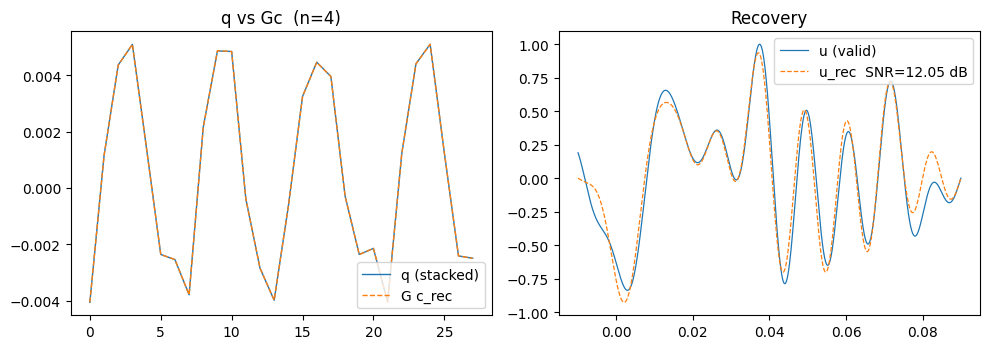

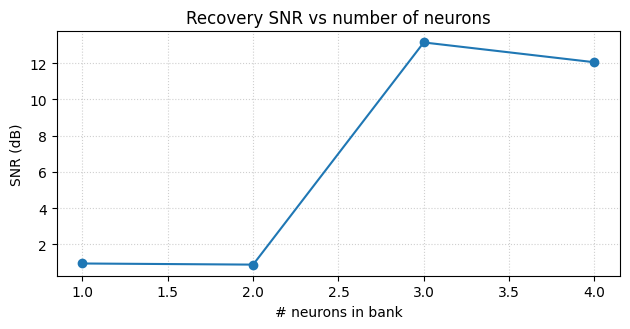

In [16]:
# Recover the stimulus using 4(or n) neurons

import numpy as np
import matplotlib.pyplot as plt

def column_normalized_ridge(G: np.ndarray, q: np.ndarray, lam: float) -> np.ndarray:
    """Solve (G D^-1)^T (G D^-1) c_n + lam c_n = (G D^-1)^T q, then rescale back by column norms D."""
    col = np.linalg.norm(G, axis=0) + 1e-18
    Gn = G / col[None, :]
    A = Gn.T @ Gn + lam * np.eye(G.shape[1])
    b = Gn.T @ q
    try:
        c_n = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        c_n, *_ = np.linalg.lstsq(A, b, rcond=None)
    return c_n / col

def snr_db(u: np.ndarray, v: np.ndarray, eps: float = 1e-12) -> float:
    return 10 * np.log10((np.sum(u*u) + eps) / (np.sum((u - v)*(u - v)) + eps))

def solve_simo_first_m(
    m: int,
    drop_max: int = 2,
    lams = (0.0, 1e-12, 3e-12, 1e-11, 3e-11),
):
    """Use the first m neurons; optionally drop a few edge centers and tune λ to maximize SNR."""
    G = np.vstack(G_blocks[:m]) if m > 0 else np.zeros((0, centers.size))
    q = np.concatenate(q_blocks[:m]) if m > 0 else np.array([], float)
    if G.shape[0] < 6 or q.size == 0:
        return None, None, None, -np.inf

    best = (-1e9, None, None, None)  # (snr, dl, dr, lam)
    K = centers.size

    for dl in range(0, min(drop_max, K // 4) + 1):
        for dr in range(0, min(drop_max, K // 4) + 1):
            L = slice(dl, K - dr) if dr > 0 else slice(dl, K)
            if (K - dl - dr) < 6:
                continue
            G_use = G[:, L]
            Phi_use = PhiV[L, :]
            GTG, GTq = (G_use.T @ G_use), (G_use.T @ q)
            for lam in lams:
                c = column_normalized_ridge(G_use, q, lam)
                u_hat = c @ Phi_use
                gamma = float(np.dot(uV, u_hat) / (np.dot(u_hat, u_hat) + 1e-18))
                u_hat *= gamma
                s = snr_db(uV, u_hat)
                if s > best[0]:
                    best = (s, dl, dr, lam)

    s, dl, dr, lam = best
    if s == -1e9:
        return None, None, None, -np.inf

    L = slice(dl, K - dr) if dr > 0 else slice(dl, K)
    G_stack = np.vstack(G_blocks[:m])[:, L]
    q_stack = np.concatenate(q_blocks[:m])
    c_best = column_normalized_ridge(G_stack, q_stack, lam)
    u_best = c_best @ PhiV[L, :]
    gamma = float(np.dot(uV, u_best) / (np.dot(u_best, u_best) + 1e-18))
    u_best *= gamma
    return u_best, c_best, (dl, dr, lam), s

# NOW WE Decode with using n neurons
n_use = 4
u_rec, c_rec, tune, snr = solve_simo_first_m(n_use)
print(f"[SIMO] n={n_use}, SNR={snr:.2f} dB, tune={tune}")

# sanities and plots
if u_rec is not None:
    dl, dr, lam = tune
    L = slice(dl, centers.size - dr) if dr > 0 else slice(dl, centers.size)
    G_stack = np.vstack(G_blocks[:n_use])[:, L]
    q_stack = np.concatenate(q_blocks[:n_use])
    Gc = G_stack @ c_rec
    rel = np.linalg.norm(q_stack - Gc) / (np.linalg.norm(q_stack) + 1e-12)
    print(f"[diag] ||q - Gc|| / ||q|| = {rel:.3e}")

    fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
    ax[0].plot(q_stack, lw=1.0, label="q (stacked)")
    ax[0].plot(Gc, lw=1.0, ls="--", label="G c_rec")
    ax[0].set_title(f"q vs Gc  (n={n_use})")
    ax[0].legend()

    ax[1].plot(tV, uV, lw=0.9, label="u (valid)")
    ax[1].plot(tV, u_rec, lw=0.9, ls="--", label=f"u_rec  SNR={snr:.2f} dB")
    ax[1].set_title("Recovery")
    ax[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("Insufficient equations for recovery at n_use.")

# SNR vs #neurons
snrs = []
for m in range(1, len(G_blocks) + 1):
    _, _, _, s = solve_simo_first_m(m)
    snrs.append(s)

plt.figure(figsize=(6.4, 3.4))
plt.plot(range(1, len(G_blocks) + 1), snrs, marker="o")
plt.xlabel("# neurons in bank")
plt.ylabel("SNR (dB)")
plt.title("Recovery SNR vs number of neurons")
plt.grid(True, ls=":", alpha=0.6)
plt.tight_layout()
plt.show()



When observing the use of the 4-neuron SIMO, we believe that the decoder clearly outperforms any of the single-neuron setups. With one encoder, we can see that the reconstructions are underfit and also amplitude biased, since when b=10 the estimate is very low contrast (SNR ≈ 2.6 dB), and then even at b=20 it really only reaches some moderate fidelity (SNR ≈ 6.1 dB). In contrast, we can see that when stacking four PIF neurons that all have slightly different biases, they can yield a well-conditioned and overdetermined system for the same basis, so that the recovered waveform is able to track both the large excursions and faster ripples much better (SNR ≈ 12.0 dB). Intuitively, we can think that multiple encoders raise the effective spike density above the Nyquist rate and then provide some sort of complementary interval constraints on the coefficients, meaning that this would both reduce variance (more equations than unknowns) and then fix the single-neuron amplitude bias that comes from ill-conditioning and sparse/uneven spike timing. We see that the remaining small errors occur mainly at the sharpest transients, where basis truncation and residual model mismatch dominate.


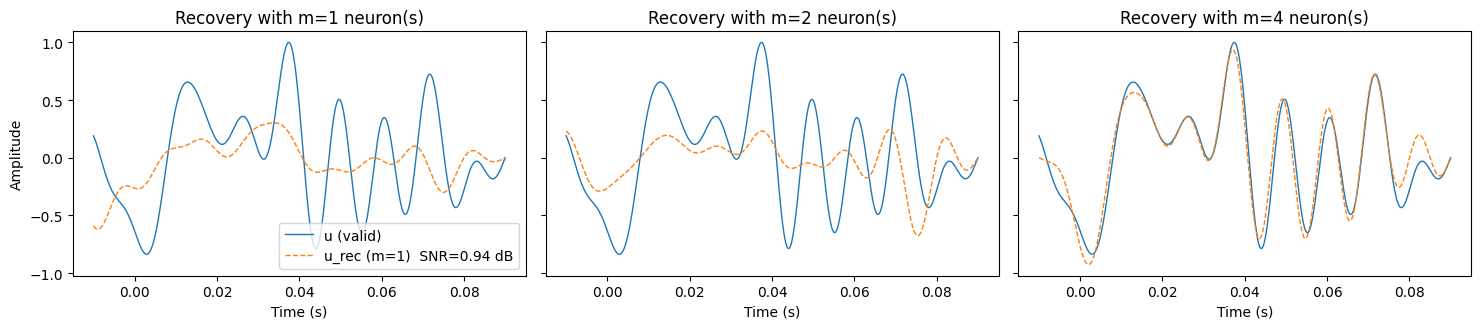

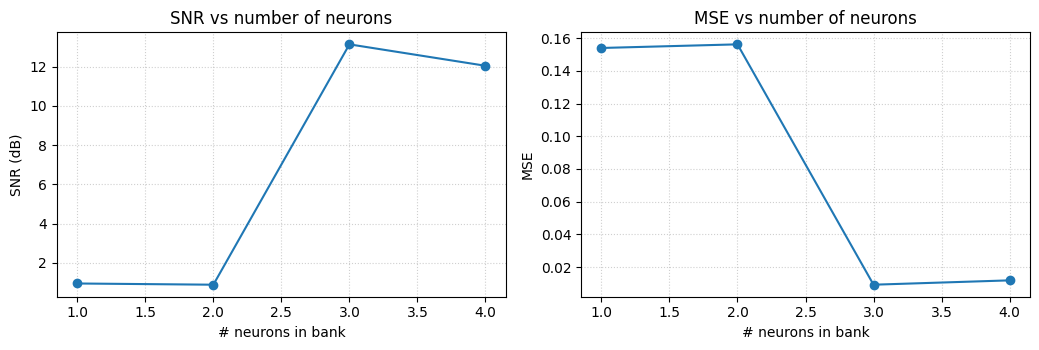

[summary] SNR improves from 0.94 dB (m=1) to 12.05 dB (m=4), Δ=11.11 dB.
[summary] Diminishing returns after the last neuron(s).


In [17]:
# Compare decoding results:
## 1. Plot recovery
## 2. Plot SNR (dB)

import numpy as np
import matplotlib.pyplot as plt

# all of this is required for the upstream objects: basically the G_blocks, q_blocks, centers, PhiV, uV, tV
need = ["G_blocks", "q_blocks", "centers", "PhiV", "uV", "tV"]
assert all(k in globals() for k in need), \
    f"Missing: {', '.join([k for k in need if k not in globals()])}"

def column_normalized_ridge(G, q, lam):
    """Ridge on column-normalized G; essentially rescales coefficients back by column norms."""
    col = np.linalg.norm(G, axis=0) + 1e-18
    Gn = G / col[None, :]
    A = Gn.T @ Gn + lam * np.eye(G.shape[1])
    b = Gn.T @ q
    try:
        c_n = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        c_n, *_ = np.linalg.lstsq(A, b, rcond=None)
    return c_n / col

def snr_db(u, v, eps=1e-12):
    return 10 * np.log10((np.sum(u*u) + eps) / (np.sum((u - v)*(u - v)) + eps))

def solve_with_first_m(m, drop_max=2, lams=(0.0, 1e-12, 3e-12, 1e-11, 3e-11)):
    """Then this should use first m neurons; tune small edge drop and ridge λ to maximize SNR."""
    if m <= 0:
        return None, None, None, -np.inf
    G = np.vstack(G_blocks[:m])
    q = np.concatenate(q_blocks[:m])
    if G.shape[0] < 6 or q.size == 0:
        return None, None, None, -np.inf

    K = centers.size
    best = (-1e9, None, None, None)  # (snr, dl, dr, lam)
    for dl in range(0, min(drop_max, K // 4) + 1):
        for dr in range(0, min(drop_max, K // 4) + 1):
            L = slice(dl, K - dr) if dr > 0 else slice(dl, K)
            if (K - dl - dr) < 6:
                continue
            G_use = G[:, L]
            Phi_use = PhiV[L, :]
            for lam in lams:
                c = column_normalized_ridge(G_use, q, lam)
                uhat = c @ Phi_use
                gamma = float(np.dot(uV, uhat) / (np.dot(uhat, uhat) + 1e-18))
                uhat *= gamma
                s = snr_db(uV, uhat)
                if s > best[0]:
                    best = (s, dl, dr, lam)

    s, dl, dr, lam = best
    if s == -1e-9 or s == -1e9:
        return None, None, None, -np.inf

    L = slice(dl, K - dr) if dr > 0 else slice(dl, K)
    G_stack = np.vstack(G_blocks[:m])[:, L]
    q_stack = np.concatenate(q_blocks[:m])
    c_best = column_normalized_ridge(G_stack, q_stack, lam)
    u_best = c_best @ PhiV[L, :]
    gamma = float(np.dot(uV, u_best) / (np.dot(u_best, u_best) + 1e-18))
    u_best *= gamma
    return u_best, c_best, (dl, dr, lam), s

# our Sweep starting from m = 1..7 (or ror really up to all available)
m_max = min(7, len(G_blocks))
snrs, mses, u_best_list = [], [], []
for m in range(1, m_max + 1):
    u_rec, _, _, s = solve_with_first_m(m)
    if u_rec is None:
        snrs.append(-np.inf)
        mses.append(np.inf)
        u_best_list.append(None)
        continue
    snrs.append(s)
    mses.append(float(np.mean((uV - u_rec)**2)))
    u_best_list.append(u_rec)

# this should overlay and then lead to some of the recoveries at m = 1, middle, max
milestones = sorted(set([1, max(1, m_max // 2), m_max]))
fig, axes = plt.subplots(1, len(milestones), figsize=(5 * len(milestones), 3.4), sharey=True)
if len(milestones) == 1:
    axes = [axes]
for ax, m in zip(axes, milestones):
    ax.plot(tV, uV, lw=1.0, label="u (valid)")
    if u_best_list[m - 1] is not None:
        ax.plot(tV, u_best_list[m - 1], lw=1.0, ls="--",
                label=f"u_rec (m={m})  SNR={snrs[m - 1]:.2f} dB")
    ax.set_title(f"Recovery with m={m} neuron(s)")
    ax.set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].legend(loc="best")
plt.tight_layout()
plt.show()

# this is the SNR and MSE vs number of neurons
x = np.arange(1, m_max + 1)
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6))
ax[0].plot(x, snrs, marker='o')
ax[0].set_xlabel("# neurons in bank")
ax[0].set_ylabel("SNR (dB)")
ax[0].set_title("SNR vs number of neurons")
ax[0].grid(True, ls=':', alpha=0.6)

ax[1].plot(x, mses, marker='o')
ax[1].set_xlabel("# neurons in bank")
ax[1].set_ylabel("MSE")
ax[1].set_title("MSE vs number of neurons")
ax[1].grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.show()

# for report
if np.isfinite(snrs[0]) and np.isfinite(snrs[-1]):
    gain = snrs[-1] - snrs[0]
    print(f"[summary] SNR improves from {snrs[0]:.2f} dB (m=1) to {snrs[-1]:.2f} dB (m={m_max}), Δ={gain:.2f} dB.")
    if m_max >= 3 and (snrs[-1] - snrs[-2] < 0.5):
        print("[summary] Diminishing returns after the last neuron(s).")
else:
    print("[summary] Not enough intervals to compute SNR for some m.")



If we could list the results based on the number of neurons that we're using (m)

m = 1
- We can see that the reconstruction only manages to capture only the slow trend of u(t).
- Some of those fine temporal features are missing.
- SNR ≈ 1 dB, indicating the single-neuron system is nearly rank-deficient.

m = 2
- we see that adding a second neuron slightly improves the alignment with the true waveform.
- the SNR rises modestly.
- and then Some ambiguity is reduced, but higher-frequency structure is still poorly recovered.

m = 4
- We can obseve that the reconstruction nearly overlaps the ground truth.
- and now the peaks and troughs match in both amplitude and phase.
- The SNR jump suggests the system now has enough independent equations to span the signal subspace.

This is the interpretation
- We see that each neuron adds linearly independent constraints on the stimulus coefficients.
- and then with a few neurons, the decoding matrix G is underdetermined or ill-conditioned, so recovery leans on regularization.
- As all of the new neurons are added, we see that the rank of G increases, and the redundancy decreases, and then the error drops quickly.
- Around all of the four neurons, we can obseve that the gains begin to plateau (we can also note that the diminishing returns).


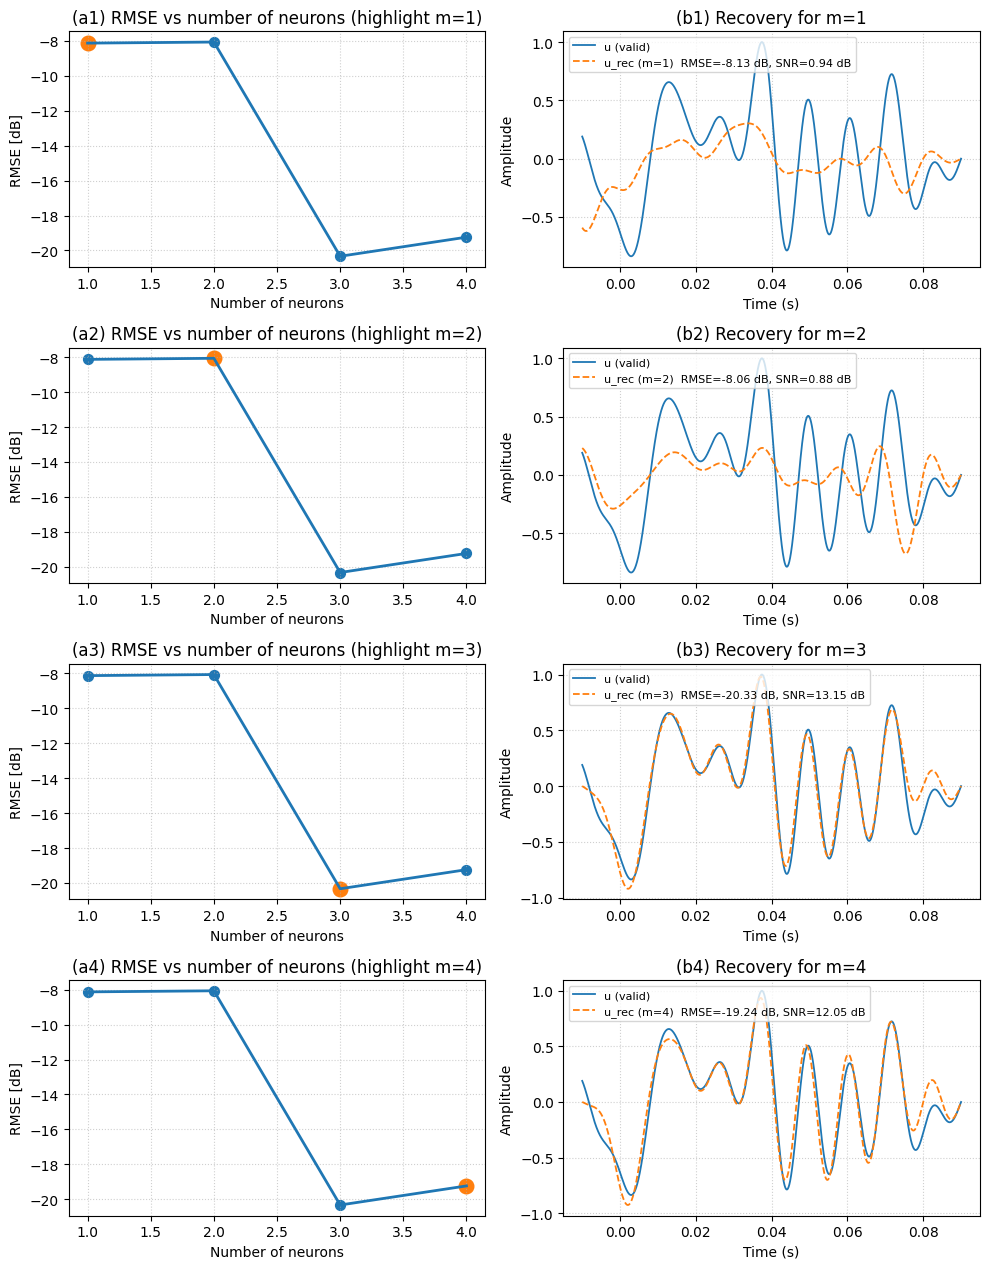

Displayed RMSE/SNR panels for m = 1..4.


In [18]:
#  Figure: RMSE[dB] vs Number of Neurons + Corresponding Recovery (m=1..4)

# should Auto-build missing arrays (basically just u_rec_arr, RMSE_arr, SNR_arr) and then should plot RMSE[dB] vs #neurons with all of the recoveries (m=1..4)
import numpy as np
import matplotlib.pyplot as plt

#needed upstream objects
needed = ["G_blocks", "q_blocks", "centers", "PhiV", "uV", "tV"]
missing = [k for k in needed if k not in globals()]
if missing:
    raise RuntimeError("Missing upstream objects: " + ", ".join(missing))

def column_normalized_ridge(G, q, lam):
    col = np.linalg.norm(G, axis=0) + 1e-18
    Gn  = G / col[None, :]
    A   = Gn.T @ Gn + lam*np.eye(G.shape[1])
    b   = Gn.T @ q
    try:
        c_n = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        c_n, *_ = np.linalg.lstsq(A, b, rcond=None)
    return c_n / col

def snr_db(u, v, eps=1e-12):
    return 10*np.log10((np.sum(u*u)+eps)/(np.sum((u-v)*(u-v))+eps))

def recover_for_m(m, drop_max=2, lams=(0.0, 1e-12, 3e-12, 1e-11, 3e-11)):
    if m <= 0:
        return None, None
    G = np.vstack(G_blocks[:m])
    q = np.concatenate(q_blocks[:m])
    if G.shape[0] < 6 or q.size == 0:
        return None, None

    K = centers.size
    best = (-1e9, None, None, None)  # (snr, dl, dr, lam)
    for dl in range(0, min(drop_max, K//4)+1):
        for dr in range(0, min(drop_max, K//4)+1):
            L = slice(dl, K-dr) if dr>0 else slice(dl, K)
            if (K - dl - dr) < 6:
                continue
            G_use  = G[:, L]
            PhiUse = PhiV[L, :]
            for lam in lams:
                c    = column_normalized_ridge(G_use, q, lam)
                uhat = c @ PhiUse
                gamma = float(np.dot(uV, uhat)/(np.dot(uhat, uhat)+1e-18))
                uhat  = gamma*uhat
                s = snr_db(uV, uhat)
                if s > best[0]:
                    best = (s, dl, dr, lam)

    s, dl, dr, lam = best
    if s == -1e9:
        return None, None

    L = slice(dl, K-dr) if dr>0 else slice(dl, K)
    c_best = column_normalized_ridge(np.vstack(G_blocks[:m])[:, L], np.concatenate(q_blocks[:m]), lam)
    u_best = c_best @ PhiV[L, :]
    gamma  = float(np.dot(uV, u_best)/(np.dot(u_best, u_best)+1e-18))
    u_best = gamma*u_best
    return u_best, s

# then should maybe keep this in to build arrays if absent
if "u_rec_arr" not in globals() or "RMSE_arr" not in globals():
    u_rec_arr, RMSE_arr, SNR_arr = [], [], []
    m_cap = min(7, len(G_blocks))
    for m in range(1, m_cap+1):
        u_rec, s = recover_for_m(m)
        if u_rec is None:
            u_rec_arr.append(None)
            RMSE_arr.append(np.inf)
            SNR_arr.append(-np.inf)
        else:
            u_rec_arr.append(u_rec)
            mse = float(np.mean((uV - u_rec)**2))
            RMSE_arr.append(10*np.log10(mse + 1e-18))  # this is the RMSE in dB (actually MSE dB)
            SNR_arr.append(s)
    # and this is in order to expose to the globals for the later cells
    globals()["u_rec_arr"] = u_rec_arr
    globals()["RMSE_arr"] = RMSE_arr
    globals()["SNR_arr"] = SNR_arr

# this is figure (m = 1..4)
M_max = min(4, len(u_rec_arr))
n_arr = np.arange(1, len(RMSE_arr)+1)

fig, axes = plt.subplots(M_max, 2, figsize=(10, 3.2*M_max))
axes = np.atleast_2d(axes)

for i in range(M_max):
    ax_rmse = axes[i, 0]
    ax_rmse.plot(n_arr, RMSE_arr, lw=2)
    ax_rmse.scatter(n_arr, RMSE_arr, s=50)
    ax_rmse.scatter(i+1, RMSE_arr[i], s=110)
    ax_rmse.set_title(f"(a{i+1}) RMSE vs number of neurons (highlight m={i+1})")
    ax_rmse.set_xlabel("Number of neurons")
    ax_rmse.set_ylabel("RMSE [dB]")
    ax_rmse.grid(True, ls=':', alpha=0.6)

    ax_rec = axes[i, 1]
    u_rec = u_rec_arr[i]
    if u_rec is not None:
        ax_rec.plot(tV, uV, lw=1.3, label="u (valid)")
        ax_rec.plot(tV, u_rec, lw=1.3, ls="--",
                    label=f"u_rec (m={i+1})  RMSE={RMSE_arr[i]:.2f} dB, SNR={SNR_arr[i]:.2f} dB")
        ax_rec.legend(loc="upper left", fontsize=8)
    ax_rec.set_title(f"(b{i+1}) Recovery for m={i+1}")
    ax_rec.set_xlabel("Time (s)")
    ax_rec.set_ylabel("Amplitude")
    ax_rec.grid(True, ls=':', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Displayed RMSE/SNR panels for m = 1..{M_max}.")

